<h1 style="color:brown" align="center"> <b>Data Visualization with Python</b></h1>

## **Basic Plots**

In [9]:
# importing required modules
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

In [10]:
x = np.linspace(0, 10, 50)
print(x)

[ 0.          0.20408163  0.40816327  0.6122449   0.81632653  1.02040816
  1.2244898   1.42857143  1.63265306  1.83673469  2.04081633  2.24489796
  2.44897959  2.65306122  2.85714286  3.06122449  3.26530612  3.46938776
  3.67346939  3.87755102  4.08163265  4.28571429  4.48979592  4.69387755
  4.89795918  5.10204082  5.30612245  5.51020408  5.71428571  5.91836735
  6.12244898  6.32653061  6.53061224  6.73469388  6.93877551  7.14285714
  7.34693878  7.55102041  7.75510204  7.95918367  8.16326531  8.36734694
  8.57142857  8.7755102   8.97959184  9.18367347  9.3877551   9.59183673
  9.79591837 10.        ]


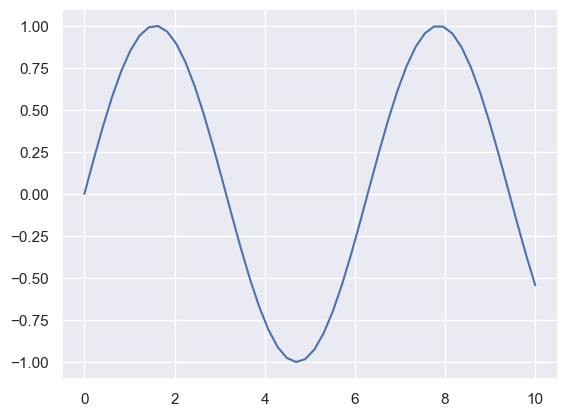

In [11]:
x = np.linspace(0, 10, 50)
sinus = np.sin(x)
plt.plot(x, sinus)
plt.show()

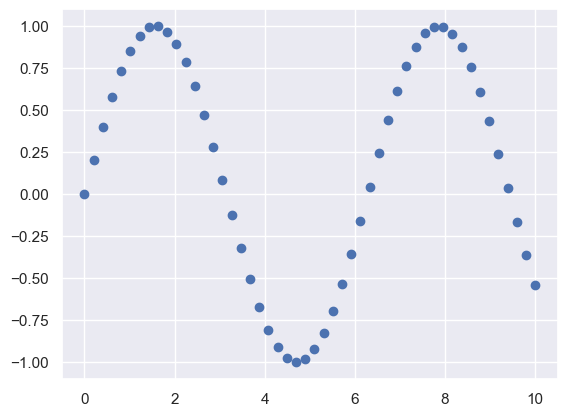

In [12]:
plt.plot(x, sinus, "o")
plt.show()

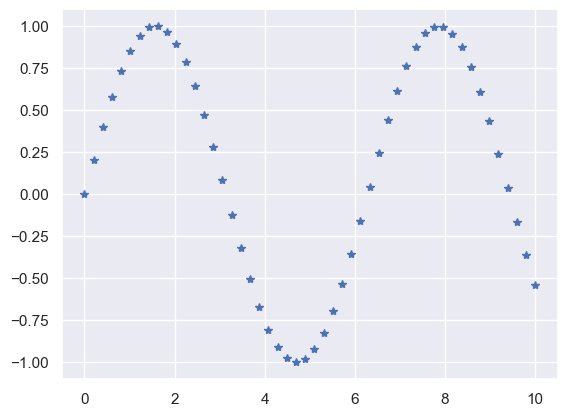

In [13]:
plt.plot(x, sinus, "*")
plt.show()

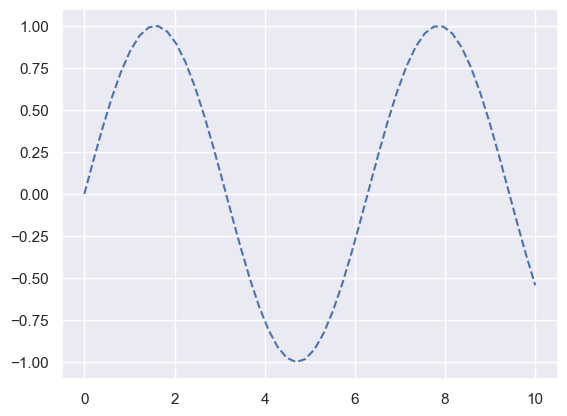

In [14]:
plt.plot(x, sinus, "--")
plt.show()

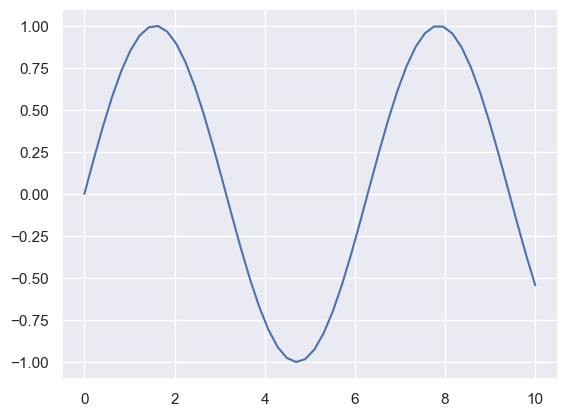

In [15]:
plt.plot(x, sinus, "-")
plt.show()

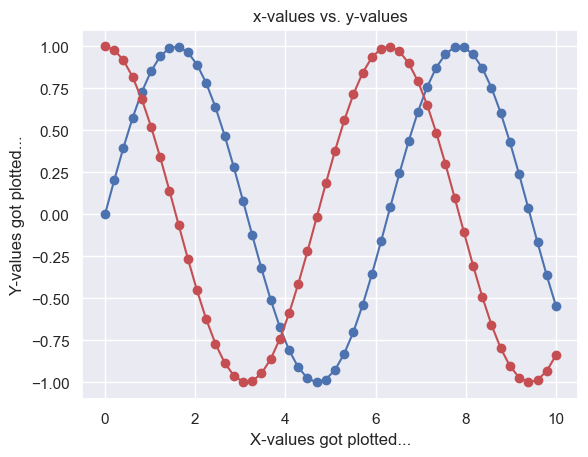

In [16]:
# rapid multiplot
x = np.linspace(0, 10, 50)
sinus = np.sin(x)
cosinus = np.cos(x)
plt.plot(x, sinus, "-b", x, sinus, "ob", x, cosinus, "-r", x, cosinus, "or")
plt.xlabel("X-values got plotted...")
plt.ylabel("Y-values got plotted...")
plt.title("x-values vs. y-values")
plt.show()

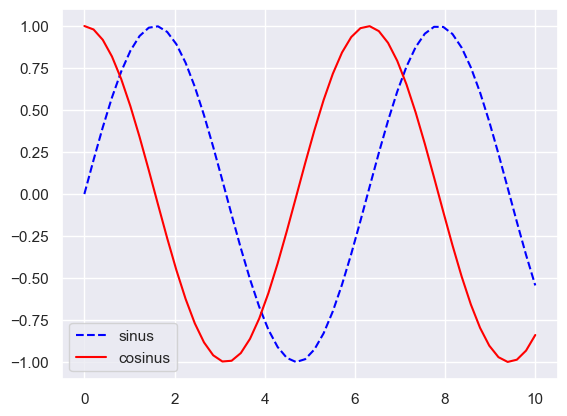

In [17]:
# plotting step by step
plt.plot(x, sinus, label='sinus', color='blue', linestyle='--')
plt.plot(x, cosinus, label='cosinus', color='red', linestyle='-')
plt.legend(loc = 0)
plt.show()

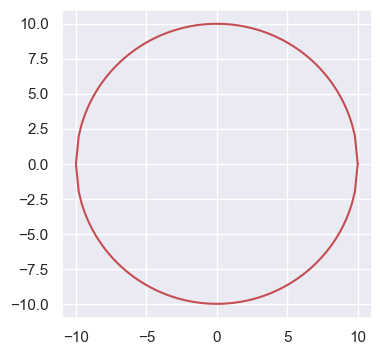

In [18]:
# x^2 + y^2 = r^2 => y = sqrt(r^2 - x^2)
r = 10
x = np.linspace(-10, 10, 100)
y = np.sqrt(r**2 - x**2)
plt.figure(figsize = (4, 4))
plt.plot(x, y, "-r")
plt.plot(x, -y, "-r")
plt.show()

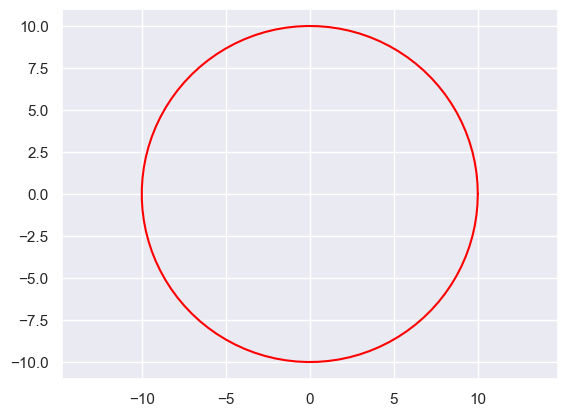

In [19]:
r = 10
theta = np.linspace(0, 2 * np.pi, 100)
x = r * np.cos(theta)
y = r * np.sin(theta)
plt.plot(x, y, color = "red")
plt.axis("equal")
plt.show()

In [20]:
# loading data files on to a dataframe
try:
    salary_df = pd.read_csv("https://raw.githubusercontent.com/toarnabtrainer/AEC_ML_Batch_1_August_2026/refs/heads/main/Datafile/salary_table.csv")
    display(salary_df.head())
except:
    print("File access error !!!")
print("Data file operation has been completed...")

,salary,experience,education,management
0,13876,1,Bachelor,Y
1,11608,1,Ph.D,N
2,18701,1,Ph.D,Y
3,11283,1,Master,N
4,11767,1,Ph.D,N


Data file operation has been completed...


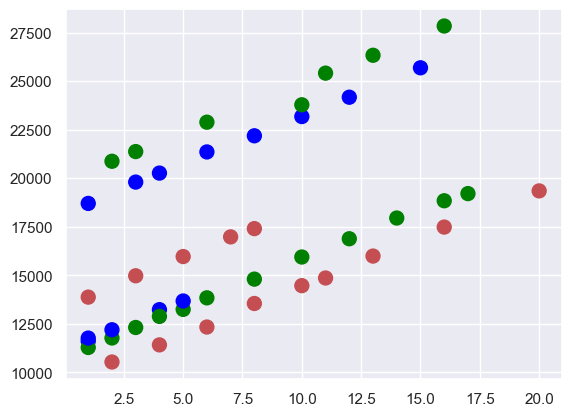

In [21]:
# simple scatter plot with colors
colors = colors_edu = {'Bachelor':'r', 'Ph.D':'blue', 'Master':'green'}
plt.scatter(salary_df.experience, salary_df.salary, c=salary_df.education.apply(lambda e:colors_edu[e]), \
           s = 100)
plt.show()

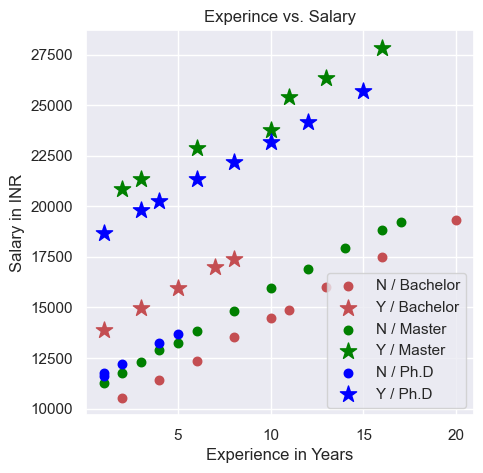

In [22]:
plt.figure(figsize=(5, 5))
symbols_manag = {"Y":'*', "N":'.'}
colors_edu = {'Bachelor':'r', 'Ph.D':'blue', 'Master':'green'}
for values, df in salary_df.groupby(['education', 'management']):
    # print("values:", values)
    # display(df)
    edu, manager = values
    plt.scatter(df.experience, df.salary, marker = symbols_manag[manager], color=colors_edu[edu], \
               s = 150, label = manager + " / " + edu)
plt.legend()
plt.xlabel("Experience in Years")
plt.ylabel("Salary in INR")
plt.title("Experince vs. Salary")
plt.show()

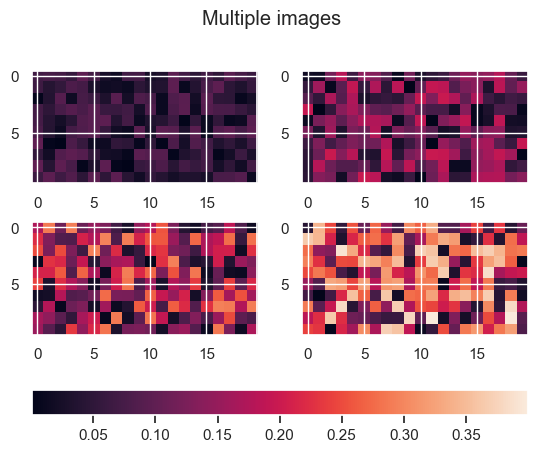

In [23]:
import matplotlib.pyplot as plt
import numpy as np

import matplotlib.colorizer as mcolorizer
import matplotlib.colors as mcolors

np.random.seed(19680801)

datasets = [
    (i+1)/10 * np.random.rand(10, 20)
    for i in range(4)
]

fig, axs = plt.subplots(2, 2)
fig.suptitle('Multiple images')

# create a colorizer with a predefined norm to be shared across all images
norm = mcolors.Normalize(vmin=np.min(datasets), vmax=np.max(datasets))
colorizer = mcolorizer.Colorizer(norm=norm)

images = []
for ax, data in zip(axs.flat, datasets):
    images.append(ax.imshow(data, colorizer=colorizer))

fig.colorbar(images[0], ax=axs, orientation='horizontal', fraction=.1)

plt.show()

AttributeError: 'Axes' object has no attribute 'pie_label'

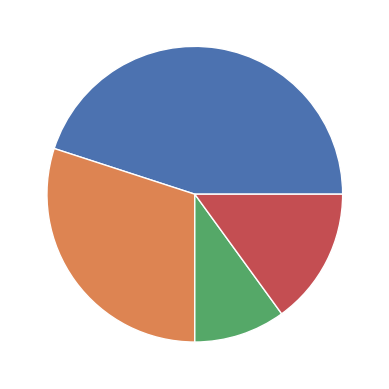

In [24]:
import matplotlib.pyplot as plt

data = [36, 24, 8, 12]
labels = ['spam', 'eggs', 'bacon', 'sausage']

fig, ax = plt.subplots()
pie = ax.pie(data)
ax.pie_label(pie, labels)

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

from matplotlib.widgets import CheckButtons

t = np.arange(0.0, 2.0, 0.01)
s0 = np.sin(2*np.pi*t)
s1 = np.sin(4*np.pi*t)
s2 = np.sin(6*np.pi*t)

fig, ax = plt.subplots()
l0, = ax.plot(t, s0, visible=False, lw=2, color='black', label='1 Hz')
l1, = ax.plot(t, s1, lw=2, color='red', label='2 Hz')
l2, = ax.plot(t, s2, lw=2, color='blue', label='3 Hz')

lines_by_label = {l.get_label(): l for l in [l0, l1, l2]}
line_colors = [l.get_color() for l in lines_by_label.values()]

# Make checkbuttons with all plotted lines with correct visibility
rax = ax.inset_axes([0.0, 0.0, 0.12, 0.2])
check = CheckButtons(
    ax=rax,
    labels=lines_by_label.keys(),
    actives=[l.get_visible() for l in lines_by_label.values()],
    label_props={'color': line_colors},
    frame_props={'edgecolor': line_colors},
    check_props={'facecolor': line_colors},
)


def callback(label):
    ln = lines_by_label[label]
    ln.set_visible(not ln.get_visible())
    ln.figure.canvas.draw_idle()

check.on_clicked(callback)

plt.show()

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme()

# Load the example flights dataset and convert to long-form
flights_long = sns.load_dataset("flights")
flights = (
    flights_long
    .pivot(index="month", columns="year", values="passengers")
)

# Draw a heatmap with the numeric values in each cell
f, ax = plt.subplots(figsize=(9, 6))
sns.heatmap(flights, annot=True, fmt="d", linewidths=.5, ax=ax)